In [2]:
library(tidyverse)
source("../scripts/00_R_presets.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘purrr’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Scanning ttf files in ../../doc/figures/helvetica ...

Extracting .afm files from .ttf files...

/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/doc/figures/helvetica/Helvetica Condensed Regular.ttf
 : Helvetica-Condensed already registered in fonts database. Skipping.

/

# Figure 3: PoreC

Subplots:
- A) PoreC Read QC
- B) Dip3D phasing records
- C) PoreC TAD Scores or something
- D) Differential Loci
- E) X chromsome inactivation

In [2]:
# Subfigure sizes
sizes <- c(
    "A" = c(5,6),
    "B" = c(3.6,1.9)    # Dip3d QC
)

In [3]:
dt_dip3d <- read_tsv("../../analysis_other/dip3d/combined_dip3d_stats.tsv", show_col_types = FALSE)

colnames(dt_dip3d)

dt_dip3d <- dt_dip3d %>%
    mutate(unphased_frags = total_frags - h1_frags - h2_frags) %>%
    select(c("sample", "tag_type", "total_reads", "reads_with_phased_frags", "total_frags", "phased_frags", "unphased_frags", "h1_frags", "h2_frags")) %>%
    pivot_longer(!c(sample, tag_type))
head(dt_dip3d)

[1] "sample"                              "tag_type"                           
 [3] "total_reads"                         "reads_with_phased_frags"            
 [5] "reads_with_phased_frags_pct"         "total_frags"                        
 [7] "phased_frags"                        "phased_frags_pct"                   
 [9] "h1_frags"                            "h1_frags_pct"                       
[11] "h2_frags"                            "h2_frags_pct"                       
[13] "contacts_dist_2147483647_h1"         "contacts_dist_2147483647_h1_pct"    
[15] "contacts_dist_2147483647_h2"         "contacts_dist_2147483647_h2_pct"    
[17] "contacts_dist_2147483647_htrans"     "contacts_dist_2147483647_htrans_pct"
[19] "contacts_dist_2147483647_phased"     "contacts_dist_2147483647_phased_pct"
[21] "contacts_dist_2147483647_total"      "contacts_dist_50000000_h1"          
[23] "contacts_dist_50000000_h1_pct"       "contacts_dist_50000000_h2"          
[25] "contacts_dist_50000000_h2_pct"       "contacts_dist_50000000_htrans"      
[27] "contacts_dist_50000000_htrans_pct"   "contacts_dist_50000000_phased"      
[29] "contacts_dist_50000000_phased_pct"   "contacts_dist_50000000_total"       
[31] "contacts_dist_5000000_h1"            "contacts_dist_5000000_h1_pct"       
[33] "contacts_dist_5000000_h2"            "contacts_dist_5000000_h2_pct"       
[35] "contacts_dist_5000000_htrans"        "contacts_dist_5000000_htrans_pct"   
[37] "contacts_dist_5000000_phased"        "contacts_dist_5000000_phased_pct"   
[39] "contacts_dist_5000000_total"

sample,tag_type,name,value
<chr>,<chr>,<chr>,<dbl>
T2T00,imputed,total_reads,1294061211
T2T00,imputed,reads_with_phased_frags,600715836
T2T00,imputed,total_frags,9923543696
T2T00,imputed,phased_frags,4815532024
T2T00,imputed,unphased_frags,5108011672
T2T00,imputed,h1_frags,2413321059


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


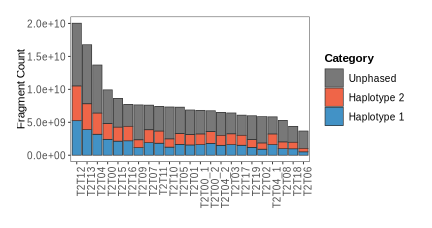

In [4]:
dt_dip3d_frags <- dt_dip3d %>%
     filter(name %in% c("unphased_frags", "h1_frags", "h2_frags")) %>%
     filter(tag_type == "imputed") %>%
     mutate( name = factor(name, levels = c("unphased_frags", "h2_frags", "h1_frags" )))

# Calculate total fragments per sample for sorting
sample_order <- dt_dip3d_frags %>%
    group_by(sample) %>%
    summarise(total = sum(value)) %>%
    arrange(desc(total)) %>%
    pull(sample)

dt_dip3d_frags <- dt_dip3d_frags %>%
    mutate(sample = factor(sample, levels = sample_order))

fig3_B_dip3d_stat <- ggplot(dt_dip3d_frags,
         aes(x = sample, y = value, fill = name)) +
    geom_bar(stat = "identity", position = "stack", col = "grey20", size = 0.2) +
    scale_fill_manual(values = col_haplotype,
                      labels = c("h1_frags" = "Haplotype 1", 
                                 "h2_frags" = "Haplotype 2", 
                                 "unphased_frags" = "Unphased")) +
    labs(x = element_blank(), y = "Fragment Count", fill = "Category") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    theme(panel.grid = element_blank())

ggsave("../../doc/figures/fig3_B_dip3d_stat.png", fig3_B_dip3d_stat, width = sizes["B1"] , height = sizes["B2"])
ggsave("../../doc/figures/fig3_B_dip3d_stat.pdf", fig3_B_dip3d_stat, width = sizes["B1"] , height = sizes["B2"])

options(repr.plot.width = sizes["B1"], repr.plot.height = sizes["B2"])
fig3_B_dip3d_stat

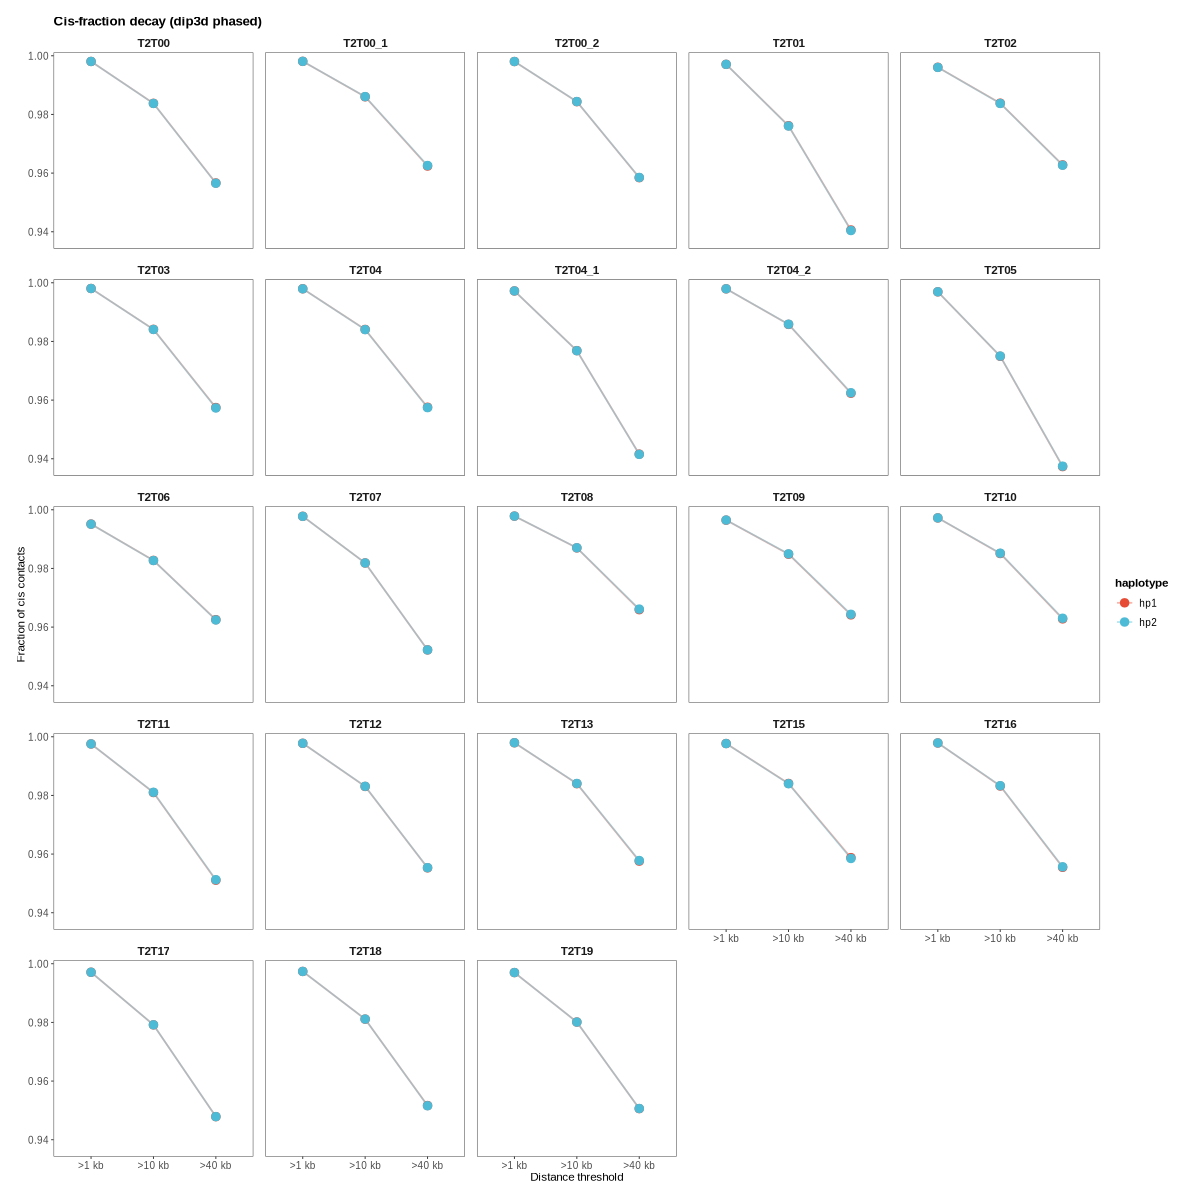

In [ ]:
df <- read_tsv("../../doc/tables/for_plots/porec_stats_summary.tsv", show_col_types = FALSE)

df_phased <- df |>
  filter(pipeline == "dip3d") |>
  pivot_longer(cols = c(frac_cis_1kb, frac_cis_10kb, frac_cis_40kb),
               names_to = "distance", values_to = "frac_cis_at_dist") |>
  mutate(distance = factor(distance,
    levels = c("frac_cis_1kb", "frac_cis_10kb", "frac_cis_40kb"),
    labels = c(">1 kb", ">10 kb", ">40 kb")))

p_summary <-ggplot(df_phased, aes(x = distance, y = frac_cis_at_dist, colour = haplotype, group = haplotype)) +
  geom_line(alpha = 0.4) +
  geom_point(size = 2) +
  facet_wrap(~sample, ncol = 5) +
  scale_colour_manual(values = c(hp1 = "#E64B35", hp2 = "#4DBBD5")) +
  labs(title = "Cis-fraction decay (dip3d phased)",
       x = "Distance threshold", y = "Fraction of cis contacts")

options(repr.plot.width = 10, repr.plot.height = 10)
p_summary




In [4]:
porec_raw <- read_tsv("../../doc/tables/for_plots/porec_stats_summary.tsv",
                      show_col_types = FALSE) %>%
  filter(pipeline == "wf-pore-c", haplotype == "unphased") %>%
  transmute(
    sample,
    pct_unmapped     = unmapped_rate     * 100,
    pct_single_sided = single_sided_rate * 100,
    pct_both_mapped  = mapping_rate      * 100,
    pct_cis          = frac_cis          * mapping_rate * 100,
    pct_trans        = (1 - frac_cis)    * mapping_rate * 100
  )

dip3d_raw <- read_tsv("../../analysis_other/dip3d/combined_dip3d_stats.tsv",
                      show_col_types = FALSE) %>%
  select(sample, tag_type, reads_with_phased_frags_pct, phased_frags_pct) %>%
  pivot_wider(names_from  = tag_type,
              values_from = c(reads_with_phased_frags_pct, phased_frags_pct),
              names_sep   = "_")

porec_breakdown <- porec_raw %>%
  left_join(dip3d_raw, by = "sample") %>%
  transmute(
    sample,
    # Bottleneck 1: alignment failure (contact level)
    pct_unmapped,
    pct_single_sided,
    # Bottleneck 2: trans contacts can't be used by Dip3D cis-phasing
    pct_trans,
    # Bottleneck 3: cis contacts with no phased-SNP overlap (before imputation)
    `frags_snp_tagged_%`   = `phased_frags_pct_snp-tagged`,
    `frags_cis_imputed_%`  = phased_frags_pct_imputed,
    `gain_from_imputation` = phased_frags_pct_imputed - `phased_frags_pct_snp-tagged`,
    # Final read-level assignment rate
    `reads_assigned_%`     = `reads_with_phased_frags_pct_imputed`
  )

print(porec_breakdown, n = Inf)

# Cohort medians
porec_breakdown %>%
  summarise(across(where(is.numeric), ~ round(median(.x, na.rm = TRUE), 1))) %>%
  pivot_longer(everything(), names_to = "metric", values_to = "median_%")

# A tibble: 23 × 8
   sample  pct_unmapped pct_single_sided pct_trans `frags_snp_tagged_%`
   <chr>          <dbl>            <dbl>     <dbl>                <dbl>
 1 T2T00           6.91             28.8      30.1                 12.8
 2 T2T00_1         6.95             29.2      31.2                 13.1
 3 T2T00_2         6.49             28.4      28.9                 13.1
 4 T2T01           7.69             28.8      25.3                 13.3
 5 T2T02           7.00             29.5      38.6                 12.4
 6 T2T03           6.78             28.2      27.8                 13.8
 7 T2T04           7.13             29.1      30.6                 12.5
 8 T2T04_1         6.61             28.5      23.8                 13.1
 9 T2T04_2         5.84             27.6      33.1                 13.2
10 T2T05           8.56             28.7      25.0                 13.1
11 T2T06           7.10             30.1      40.6                 12.2
12 T2T07           6.80             28.0     

metric,median_%
<chr>,<dbl>
pct_unmapped,6.9
pct_single_sided,28.8
pct_trans,29.5
frags_snp_tagged_%,13.1
frags_cis_imputed_%,46.6
gain_from_imputation,34.1
reads_assigned_%,46.7


In [6]:
df_unphased <- df |>
  filter(pipeline == "wf-pore-c") |>
  mutate(
    pct_mapped        = total_mapped            / total,
    pct_single_sided  = total_single_sided_mapped / total,
    pct_unmapped      = total_unmapped           / total
  ) |>
  pivot_longer(cols = c(pct_mapped, pct_single_sided, pct_unmapped),
               names_to = "outcome", values_to = "fraction") |>
  mutate(outcome = factor(outcome,
    levels = c("pct_unmapped", "pct_single_sided", "pct_mapped"),
    labels = c("Unmapped", "Single-sided", "Both mapped")))

p_mapping <- ggplot(df_unphased, aes(x = sample, y = fraction, fill = outcome)) +
  geom_col() +
  scale_fill_manual(values = c("Both mapped" = "#00A087", "Single-sided" = "#F39B7F", "Unmapped" = "#DC0000")) +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Mapping outcome per sample (wf-pore-c unphased)",
       x = NULL, y = "Fraction of read-pairs", fill = NULL) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

options(repr.plot.width = 4, repr.plot.height = 3)
ggsave("../../doc/figures/fig3_mapping_outcome.png", p_mapping, width = 4 , height = 3)


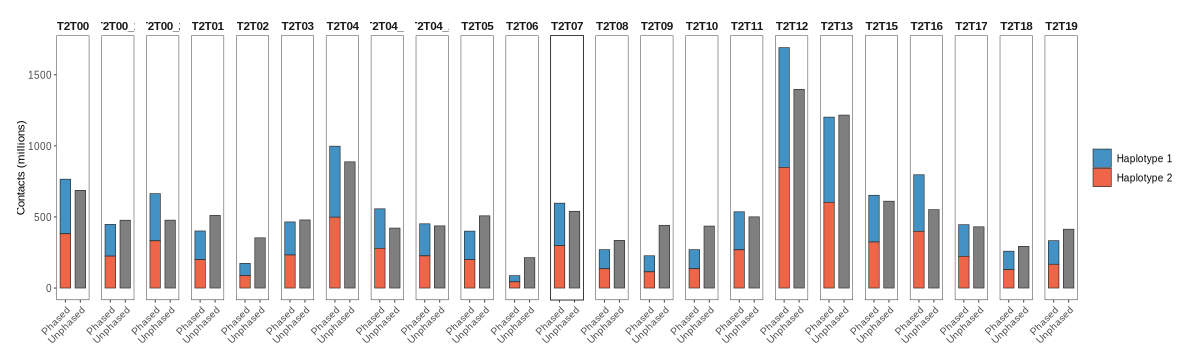

In [ ]:
unphased_counts <- df |>
  filter(pipeline == "wf-pore-c") |>
  select(sample, unphased = total_nodups)

phased_counts <- df |>
  filter(pipeline == "dip3d") |>
  select(sample, haplotype, total_nodups) |>
  pivot_wider(names_from = haplotype, values_from = total_nodups)

cmp <- left_join(unphased_counts, phased_counts, by = "sample") |>
  pivot_longer(cols = c(unphased, hp1, hp2),
               names_to = "dataset", values_to = "n_contacts") |>
  mutate(
    dataset  = factor(dataset, levels = c("hp1", "hp2", "unphased")),
    bar_pos  = if_else(dataset == "unphased", "Unphased", "Phased"),
    bar_pos  = factor(bar_pos, levels = c("Phased", "Unphased"))
  )

p_contacts <- ggplot(cmp, aes(x = bar_pos, y = n_contacts / 1e6, fill = dataset)) +
  geom_col(position = "stack", width = 0.7, colour = "grey20", linewidth = 0.2) +
  facet_wrap(~sample, nrow = 1) +
  scale_fill_manual(
    values = col_haplotype,
    labels = c(hp1 = "Haplotype 1", hp2 = "Haplotype 2", unphased = "Unphased")
  ) +
  labs(x = NULL, y = "Contacts (millions)", fill = NULL) +
  theme(
    axis.text.x  = element_text(angle = 45, hjust = 1, size = 6),
    panel.grid   = element_blank(),
    strip.text   = element_text(size = 7)
  )

ggsave("../../doc/figures/fig3_contact_counts.png", p_contacts, width = 10, height = 3)
ggsave("../../doc/figures/fig3_contact_counts.pdf", p_contacts, width = 10, height = 3)

options(repr.plot.width = 10, repr.plot.height = 3)
p_contacts
